<a href="https://colab.research.google.com/github/kaelasyadira/KaelaAssyuraSyadira-2311531001-ImageProcessing/blob/main/IP_TugasPertemuan4_2311531001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

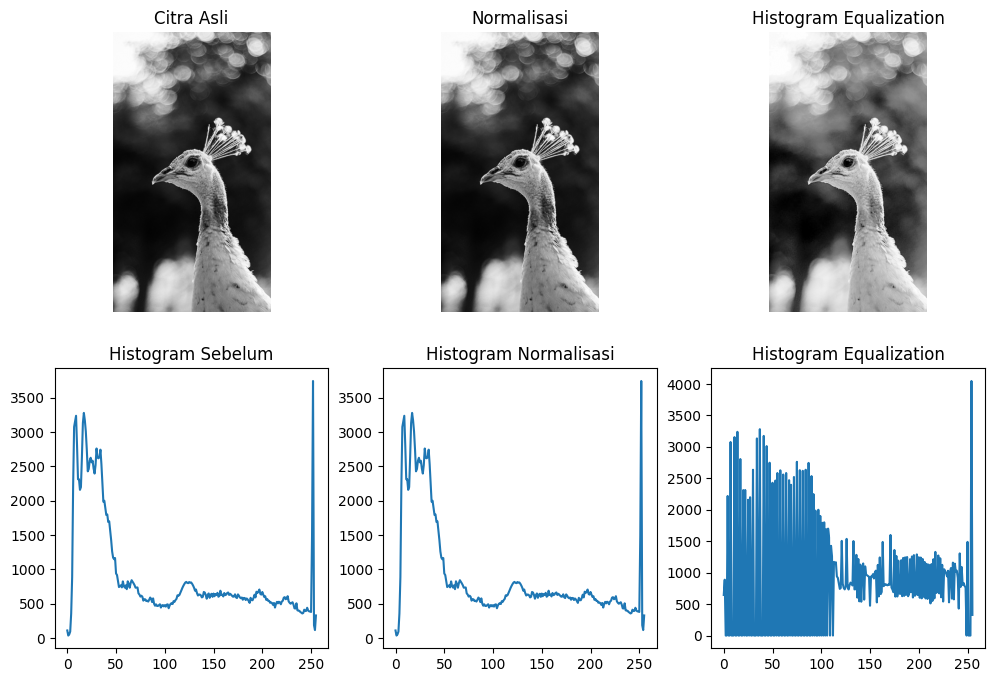

In [2]:
import cv2 #hanya openCV ini yang digunakan untuk membaca citra
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('merak.jpg', 0) #membaca gambar dengan format grayscale atau hitam putih

hist_before = np.zeros(256)

#menghitung histogram sebelum normalisasi seberapa banyak pixel yang memiliki intensitas tertentu
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        hist_before[img[i,j]] += 1

#mencari nilai minimum dan maximum untuk melakukan normalisasi histogram
min_val = np.min(img)
max_val = np.max(img)

#melakukan normalisasi histogram dengan meningkatkan kontras citra dengan memperlebar citra grayscale
norm_img = ((img - min_val) / (max_val - min_val)) * 255
norm_img = norm_img.astype(np.uint8)

#menghitung histogram citra yang sudah dinormalisasi
hist_norm = np.zeros(256)

for i in range(norm_img.shape[0]):
    for j in range(norm_img.shape[1]):
        hist_norm[norm_img[i,j]] += 1

#menghitung PDF dan CDF pada histogram untuk proses equalization
hist = np.zeros(256)

for i in range(norm_img.shape[0]):
    for j in range(norm_img.shape[1]):
        hist[norm_img[i,j]] += 1

#pdf untuk mengubah histogram menjadi distribusi probabilitas
pdf = hist / (norm_img.shape[0] * norm_img.shape[1])

#pdf untuk memetakan intensitas baru pada histogram equalization
cdf = np.zeros(256)
cdf[0] = pdf[0]

for i in range(1,256):
    cdf[i] = cdf[i-1] + pdf[i]

#membuat citra hasil histogram dengan mengubah setiap pixel dan menghasil citra dengan kontras yang lebih merata
eq_img = np.zeros_like(norm_img)

for i in range(norm_img.shape[0]):
    for j in range(norm_img.shape[1]):
        eq_img[i,j] = int(cdf[norm_img[i,j]] * 255)

#menghitung histogram setelah equalization
hist_eq = np.zeros(256)

for i in range(eq_img.shape[0]):
    for j in range(eq_img.shape[1]):
        hist_eq[eq_img[i,j]] += 1

#menampilkan hasil semua yang telah dihitung
plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.title("Citra Asli")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(2,3,2)
plt.title("Normalisasi")
plt.imshow(norm_img, cmap='gray')
plt.axis('off')

plt.subplot(2,3,3)
plt.title("Histogram Equalization")
plt.imshow(eq_img, cmap='gray')
plt.axis('off')

plt.subplot(2,3,4)
plt.title("Histogram Sebelum")
plt.plot(hist_before)

plt.subplot(2,3,5)
plt.title("Histogram Normalisasi")
plt.plot(hist_norm)

plt.subplot(2,3,6)
plt.title("Histogram Equalization")
plt.plot(hist_eq)

plt.show()


#KESIMPULAN

normalisasi hanya merentangkan nilai pixel sehingga histogram pada sebelum dan setelah normalisasi bentuknya mirip dan equalization yang membuat distribusi lebih merata.